In [1]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [4]:
dataset_path = r"C:\HOPE AI\AI Course Tamil\Smart AI Waste Classfication\dataset-resized\dataset-resized"

print("Dataset exists:", os.path.exists(dataset_path))

Dataset exists: True


In [5]:
class_names = sorted([
    folder for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
])

print("Classes:", class_names)
print("Number of classes:", len(class_names))

Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Number of classes: 6


In [6]:
image_extensions = (".jpg", ".jpeg", ".png")

for class_name in class_names:
    class_path = os.path.join(dataset_path, class_name)

    image_count = sum(
        1 for file in os.listdir(class_path)
        if file.lower().endswith(image_extensions)
    )

    print(f"{class_name}: {image_count} images")

cardboard: 403 images
glass: 501 images
metal: 410 images
paper: 594 images
plastic: 482 images
trash: 137 images


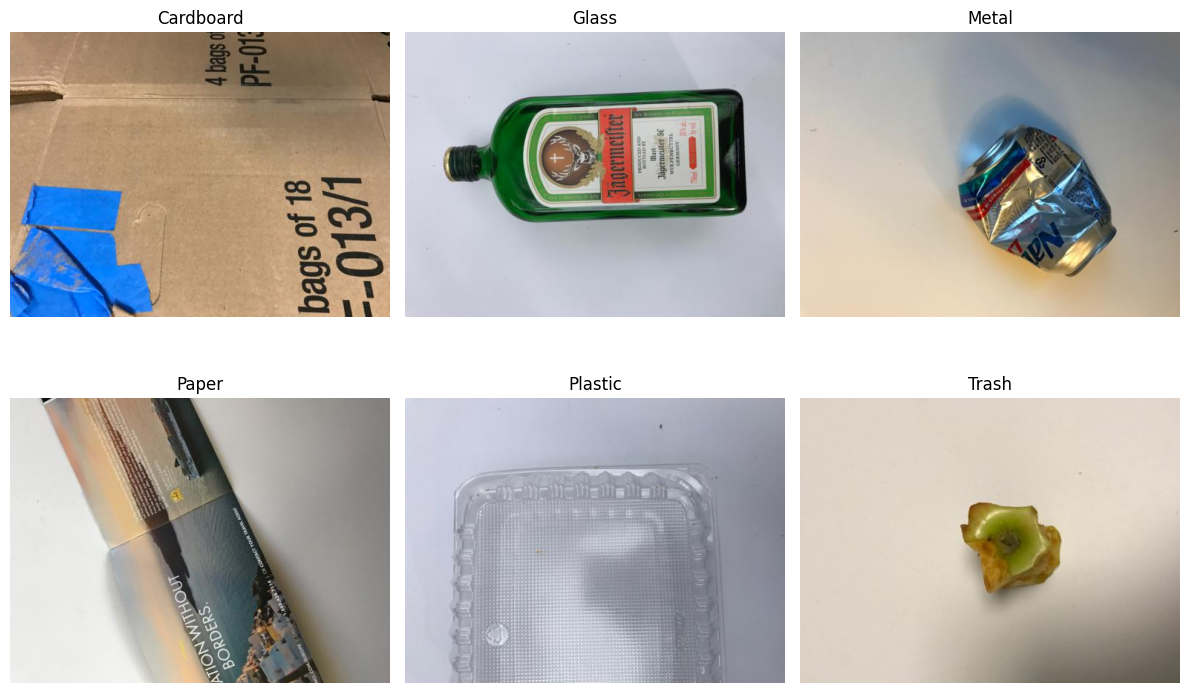

In [8]:
import random
from PIL import Image

plt.figure(figsize=(12, 8))

for i, class_name in enumerate(class_names):
    class_path = os.path.join(dataset_path, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(image_extensions)
    ]

    image_file = random.choice(image_files)
    image_path = os.path.join(class_path, image_file)

    image = Image.open(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name.capitalize())
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
from sklearn.model_selection import train_test_split

all_image_paths = []
all_labels = []

for label, class_name in enumerate(class_names):
    class_path = os.path.join(dataset_path, class_name)

    for file in os.listdir(class_path):
        if file.lower().endswith(image_extensions):
            all_image_paths.append(os.path.join(class_path, file))
            all_labels.append(label)

print("Total images:", len(all_image_paths))
print("Total labels:", len(all_labels))

Total images: 2527
Total labels: 2527


In [10]:
# First split: 80% training + 20% temporary data
X_train, X_temp, y_train, y_temp = train_test_split(
    all_image_paths,
    all_labels,
    test_size=0.20,
    random_state=42,
    stratify=all_labels
)

# Second split: temporary data into 50% validation + 50% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training images:", len(X_train))
print("Validation images:", len(X_val))
print("Testing images:", len(X_test))

Training images: 2021
Validation images: 253
Testing images: 253


In [11]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def load_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    
    return image, label


train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))

train_ds = train_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("TensorFlow datasets created successfully!")

TensorFlow datasets created successfully!


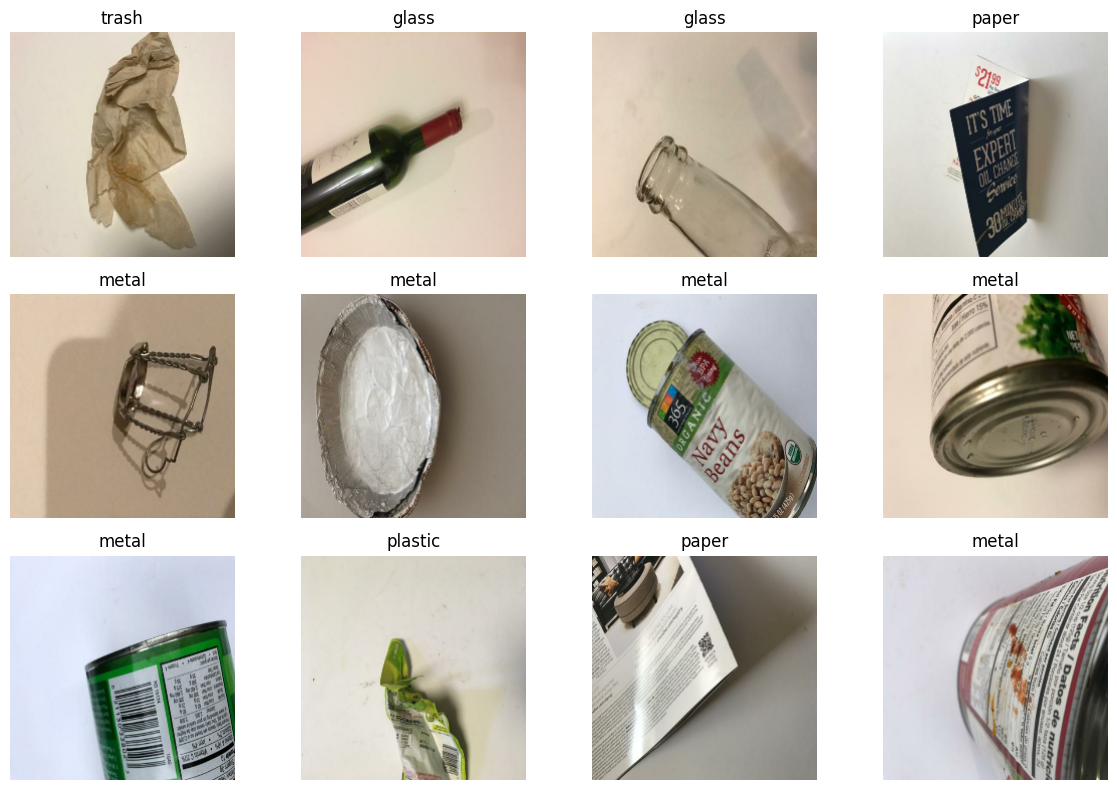

In [12]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(12):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
])

print("Data augmentation created successfully!")

Data augmentation created successfully!


In [14]:
model = tf.keras.Sequential([
    
    # Input layer
    tf.keras.layers.Input(shape=(224, 224, 3)),
    
    # Data augmentation
    data_augmentation,
    
    # Normalize pixel values
    tf.keras.layers.Rescaling(1./255),
    
    # Convolution Block 1
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    
    # Convolution Block 2
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    
    # Convolution Block 3
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    
    # Classification layers
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    
    # Output layer - 6 waste classes
    tf.keras.layers.Dense(6, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("CNN model compiled successfully!")

CNN model compiled successfully!


In [16]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

print("Early stopping created successfully!")

Early stopping created successfully!


In [17]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stopping]
)

Epoch 1/30


C:\Users\lokes\Anaconda3\envs\aiml\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


64/64 ━━━━━━━━━━━━━━━━━━━━ 38s 558ms/step - accuracy: 0.3286 - loss: 1.6248 - val_accuracy: 0.4071 - val_loss: 1.4317
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 506ms/step - accuracy: 0.4043 - loss: 1.4400 - val_accuracy: 0.4664 - val_loss: 1.3326
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 503ms/step - accuracy: 0.4339 - loss: 1.3663 - val_accuracy: 0.5415 - val_loss: 1.2478
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 502ms/step - accuracy: 0.4740 - loss: 1.3066 - val_accuracy: 0.5217 - val_loss: 1.2219
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 507ms/step - accuracy: 0.5141 - loss: 1.2306 - val_accuracy: 0.5257 - val_loss: 1.1454
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 502ms/step - accuracy: 0.5195 - loss: 1.2047 - val_accuracy: 0.5059 - val_loss: 1.1642
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 501ms/step - accuracy: 0.5443 - loss: 1.1756 - val_accuracy: 0.5415 - val_loss: 1.1314
Epoch 8/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 500ms/step - accuracy: 0.5646 - loss: 1.1313 - val_accuracy: 0.565

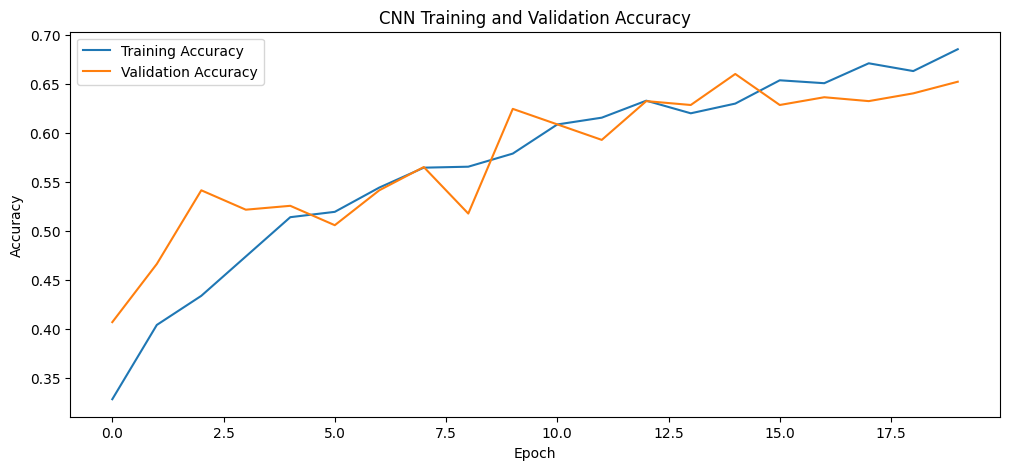

In [18]:
plt.figure(figsize=(12, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

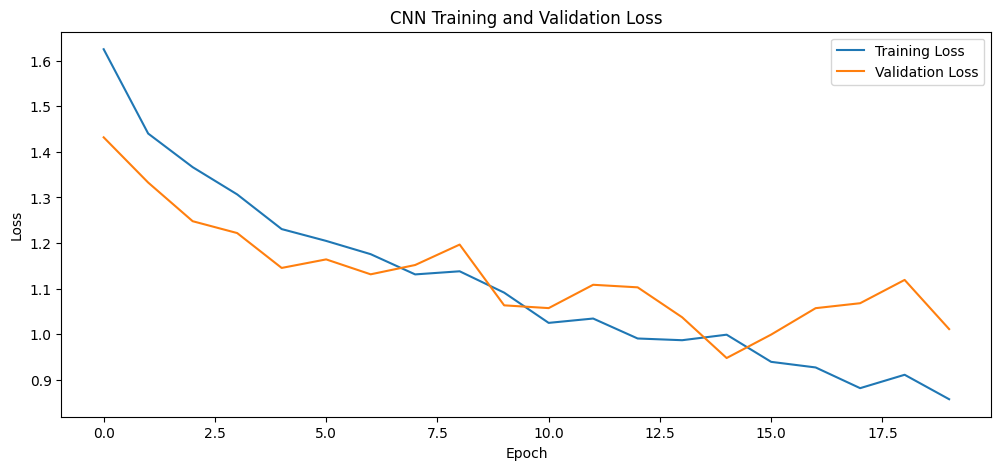

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [20]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.6798 - loss: 0.9141
Test Loss: 0.9141243100166321
Test Accuracy: 0.6798418760299683


In [21]:
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    
    predicted_classes = np.argmax(predictions, axis=1)
    
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

   cardboard       0.90      0.90      0.90        41
       glass       0.48      0.48      0.48        50
       metal       0.61      0.68      0.64        41
       paper       0.75      0.86      0.80        59
     plastic       0.67      0.57      0.62        49
       trash       0.67      0.31      0.42        13

    accuracy                           0.68       253
   macro avg       0.68      0.63      0.64       253
weighted avg       0.68      0.68      0.67       253



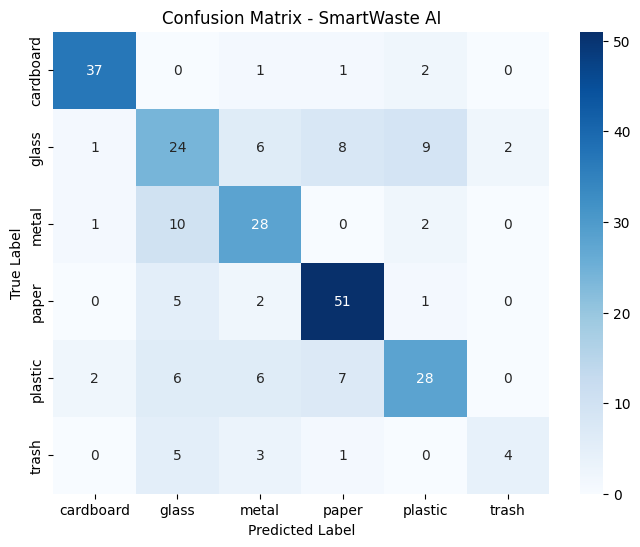

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - SmartWaste AI")
plt.show()

In [23]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(class_names)),
    y=np.array(y_train)
)

class_weights = dict(enumerate(class_weights_array))

print("Class Weights:")
for class_index, weight in class_weights.items():
    print(f"{class_names[class_index]}: {weight:.2f}")

Class Weights:
cardboard: 1.05
glass: 0.84
metal: 1.03
paper: 0.71
plastic: 0.87
trash: 3.06


In [24]:
improved_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),

    # Data augmentation
    data_augmentation,

    # Normalize pixel values
    tf.keras.layers.Rescaling(1./255),

    # CNN feature extraction
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    # Classification
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(len(class_names), activation="softmax")
])

improved_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling_1 (Rescaling)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
improved_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Improved CNN model compiled successfully!")

Improved CNN model compiled successfully!


In [26]:
improved_history = improved_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weights,
    callbacks=[early_stopping]
)

Epoch 1/30


C:\Users\lokes\Anaconda3\envs\aiml\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


64/64 ━━━━━━━━━━━━━━━━━━━━ 35s 507ms/step - accuracy: 0.2979 - loss: 1.7429 - val_accuracy: 0.3715 - val_loss: 1.4088
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 504ms/step - accuracy: 0.3746 - loss: 1.5195 - val_accuracy: 0.4150 - val_loss: 1.4048
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 504ms/step - accuracy: 0.4231 - loss: 1.4260 - val_accuracy: 0.5178 - val_loss: 1.2500
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 506ms/step - accuracy: 0.4735 - loss: 1.3091 - val_accuracy: 0.4941 - val_loss: 1.2220
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 503ms/step - accuracy: 0.4854 - loss: 1.2795 - val_accuracy: 0.5652 - val_loss: 1.1448
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 504ms/step - accuracy: 0.5235 - loss: 1.2221 - val_accuracy: 0.6008 - val_loss: 1.0985
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 503ms/step - accuracy: 0.5482 - loss: 1.1811 - val_accuracy: 0.6324 - val_loss: 1.0596
Epoch 8/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 505ms/step - accuracy: 0.5527 - loss: 1.1449 - val_accuracy: 0.592

In [27]:
improved_test_loss, improved_test_accuracy = improved_model.evaluate(test_ds)

print("Improved Test Loss:", improved_test_loss)
print("Improved Test Accuracy:", improved_test_accuracy)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.6838 - loss: 0.8470
Improved Test Loss: 0.8470346927642822
Improved Test Accuracy: 0.6837944388389587


In [28]:
y_true_improved = []
y_pred_improved = []

for images, labels in test_ds:
    predictions = improved_model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    y_true_improved.extend(labels.numpy())
    y_pred_improved.extend(predicted_classes)

print(classification_report(
    y_true_improved,
    y_pred_improved,
    target_names=class_names
))

              precision    recall  f1-score   support

   cardboard       0.92      0.80      0.86        41
       glass       0.71      0.54      0.61        50
       metal       0.66      0.66      0.66        41
       paper       0.69      0.85      0.76        59
     plastic       0.60      0.53      0.57        49
       trash       0.43      0.77      0.56        13

    accuracy                           0.68       253
   macro avg       0.67      0.69      0.67       253
weighted avg       0.70      0.68      0.68       253



In [29]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print("MobileNetV2 loaded successfully!")
print("Trainable:", base_model.trainable)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 12s 1us/step
MobileNetV2 loaded successfully!
Trainable: False


In [30]:
mobile_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),

    # Data augmentation
    data_augmentation,

    # MobileNetV2 preprocessing
    tf.keras.layers.Lambda(
        tf.keras.applications.mobilenet_v2.preprocess_input
    ),

    # Pretrained MobileNetV2
    base_model,

    # Classification layers
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(class_names), activation="softmax")
])

mobile_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda (Lambda)                      │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [31]:
mobile_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("MobileNetV2 model compiled successfully!")

MobileNetV2 model compiled successfully!


In [32]:
mobile_history = mobile_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stopping]
)

Epoch 1/20


C:\Users\lokes\Anaconda3\envs\aiml\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


64/64 ━━━━━━━━━━━━━━━━━━━━ 27s 336ms/step - accuracy: 0.5552 - loss: 1.1957 - val_accuracy: 0.7431 - val_loss: 0.6476
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 308ms/step - accuracy: 0.7293 - loss: 0.7363 - val_accuracy: 0.7866 - val_loss: 0.5617
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 309ms/step - accuracy: 0.7635 - loss: 0.6320 - val_accuracy: 0.8103 - val_loss: 0.5533
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 308ms/step - accuracy: 0.7952 - loss: 0.5713 - val_accuracy: 0.8300 - val_loss: 0.5170
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 309ms/step - accuracy: 0.8060 - loss: 0.5160 - val_accuracy: 0.8182 - val_loss: 0.5230
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 310ms/step - accuracy: 0.8318 - loss: 0.4539 - val_accuracy: 0.8221 - val_loss: 0.4641
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 308ms/step - accuracy: 0.8214 - loss: 0.4537 - val_accuracy: 0.8261 - val_loss: 0.4700
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 307ms/step - accuracy: 0.8466 - loss: 0.4225 - val_accuracy: 0.837

In [33]:
mobile_test_loss, mobile_test_accuracy = mobile_model.evaluate(test_ds)

print("MobileNetV2 Test Loss:", mobile_test_loss)
print("MobileNetV2 Test Accuracy:", mobile_test_accuracy)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 238ms/step - accuracy: 0.8617 - loss: 0.3882
MobileNetV2 Test Loss: 0.3881959021091461
MobileNetV2 Test Accuracy: 0.8616600632667542


In [34]:
mobile_y_true = []
mobile_y_pred = []

for images, labels in test_ds:
    predictions = mobile_model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    mobile_y_true.extend(labels.numpy())
    mobile_y_pred.extend(predicted_classes)

print(classification_report(
    mobile_y_true,
    mobile_y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

   cardboard       0.97      0.90      0.94        41
       glass       0.91      0.84      0.88        50
       metal       0.82      0.88      0.85        41
       paper       0.89      0.93      0.91        59
     plastic       0.77      0.84      0.80        49
       trash       0.70      0.54      0.61        13

    accuracy                           0.86       253
   macro avg       0.84      0.82      0.83       253
weighted avg       0.86      0.86      0.86       253



In [35]:
base_model.trainable = True

# Freeze the earlier layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

print("Total MobileNetV2 layers:", len(base_model.layers))
print("Trainable MobileNetV2 layers:", sum(
    layer.trainable for layer in base_model.layers
))

Total MobileNetV2 layers: 154
Trainable MobileNetV2 layers: 30


In [36]:
mobile_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("MobileNetV2 fine-tuning model recompiled successfully!")

MobileNetV2 fine-tuning model recompiled successfully!


In [37]:
fine_tune_history = mobile_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping]
)

Epoch 1/10


C:\Users\lokes\Anaconda3\envs\aiml\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


64/64 ━━━━━━━━━━━━━━━━━━━━ 37s 423ms/step - accuracy: 0.7694 - loss: 0.6825 - val_accuracy: 0.8538 - val_loss: 0.3925
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 380ms/step - accuracy: 0.8041 - loss: 0.5411 - val_accuracy: 0.8538 - val_loss: 0.3871
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 377ms/step - accuracy: 0.8308 - loss: 0.4499 - val_accuracy: 0.8498 - val_loss: 0.3893
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 381ms/step - accuracy: 0.8540 - loss: 0.3968 - val_accuracy: 0.8498 - val_loss: 0.3895
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 382ms/step - accuracy: 0.8278 - loss: 0.4388 - val_accuracy: 0.8419 - val_loss: 0.3948
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 383ms/step - accuracy: 0.8397 - loss: 0.4045 - val_accuracy: 0.8458 - val_loss: 0.3932
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 378ms/step - accuracy: 0.8669 - loss: 0.3523 - val_accuracy: 0.8538 - val_loss: 0.3949


In [38]:
fine_tune_test_loss, fine_tune_test_accuracy = mobile_model.evaluate(test_ds)

print("Fine-Tuned Test Loss:", fine_tune_test_loss)
print("Fine-Tuned Test Accuracy:", fine_tune_test_accuracy)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 251ms/step - accuracy: 0.8617 - loss: 0.3772
Fine-Tuned Test Loss: 0.3771769404411316
Fine-Tuned Test Accuracy: 0.8616600632667542


In [39]:
fine_y_true = []
fine_y_pred = []

for images, labels in test_ds:
    predictions = mobile_model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    fine_y_true.extend(labels.numpy())
    fine_y_pred.extend(predicted_classes)

print(classification_report(
    fine_y_true,
    fine_y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

   cardboard       0.97      0.90      0.94        41
       glass       0.88      0.88      0.88        50
       metal       0.89      0.83      0.86        41
       paper       0.87      0.93      0.90        59
     plastic       0.78      0.82      0.80        49
       trash       0.62      0.62      0.62        13

    accuracy                           0.86       253
   macro avg       0.84      0.83      0.83       253
weighted avg       0.86      0.86      0.86       253



In [40]:
import os

models_path = os.path.join(os.path.dirname(dataset_path), "models")
os.makedirs(models_path, exist_ok=True)

model_path = os.path.join(
    models_path,
    "smartwaste_mobilenetv2.keras"
)

mobile_model.save(model_path)

print("Model saved successfully!")
print("Saved location:", model_path)

Model saved successfully!
Saved location: C:\HOPE AI\AI Course Tamil\Smart AI Waste Classfication\dataset-resized\models\smartwaste_mobilenetv2.keras


In [42]:
loaded_model = tf.keras.models.load_model(
    model_path,
    custom_objects={
        "preprocess_input": tf.keras.applications.mobilenet_v2.preprocess_input
    }
)

print("Saved model loaded successfully!")
print("Model input shape:", loaded_model.input_shape)
print("Model output shape:", loaded_model.output_shape)

Saved model loaded successfully!
Model input shape: (None, 224, 224, 3)
Model output shape: (None, 6)


In [43]:
import random
import numpy as np
import tensorflow as tf

# Choose a random image from the plastic folder
plastic_path = os.path.join(dataset_path, "plastic")

image_files = [
    file for file in os.listdir(plastic_path)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
]

test_image = os.path.join(
    plastic_path,
    random.choice(image_files)
)

# Load and resize image
image = tf.keras.utils.load_img(
    test_image,
    target_size=IMG_SIZE
)

image_array = tf.keras.utils.img_to_array(image)
image_array = np.expand_dims(image_array, axis=0)

# Prediction using the SAVED model
predictions = loaded_model.predict(image_array, verbose=0)[0]

predicted_index = np.argmax(predictions)
predicted_class = class_names[predicted_index]
confidence = predictions[predicted_index] * 100

print("Actual folder: plastic")
print("Predicted class:", predicted_class)
print(f"Confidence: {confidence:.2f}%")
print("Image:", test_image)

Actual folder: plastic
Predicted class: plastic
Confidence: 88.69%
Image: C:\HOPE AI\AI Course Tamil\Smart AI Waste Classfication\dataset-resized\dataset-resized\plastic\plastic278.jpg
